# Can We Predict Whether a Central Park Squirrel Ignores Humans?

**Zifan Yang**
CSS Bootcamp Final Project

## Research Question

Can we predict whether a Central Park squirrel will ignore humans based on its traits, behaviors, and surroundings?

For this project, I used two datasets from the 2018 Central Park Squirrel Census. I first looked at some basic patterns in the data, then built two machine learning models, logistic regression and random forest, to see how well they could predict whether a squirrel was recorded as **indifferent to humans**.

## Project Outline

1. Load and look at the data
2. Merge and clean the two datasets
3. Explore patterns related to squirrel indifference
4. Build two classification models
5. Compare the results and discuss the limitations

## Data Sources

* [2018 Central Park Squirrel Census: Squirrel Data](https://data.cityofnewyork.us/Environment/2018-Central-Park-Squirrel-Census-Squirrel-Data/vfnx-vebw/about_data)

* [2018 Central Park Squirrel Census: Hectare Data](https://data.cityofnewyork.us/Environment/2018-Central-Park-Squirrel-Census-Hectare-Data/ej9h-v6g2/about_data)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 1. Load and Explore the Data

The squirrel dataset contains one row per sighting. The hectare dataset describes the conditions of each observation session.

In [2]:
squirrel_url = "https://data.cityofnewyork.us/api/views/vfnx-vebw/rows.csv?accessType=DOWNLOAD"
hectare_url = "https://data.cityofnewyork.us/api/views/ej9h-v6g2/rows.csv?accessType=DOWNLOAD"

squirrels = pd.read_csv(squirrel_url)
hectares = pd.read_csv(hectare_url)

print("Squirrel data shape:", squirrels.shape)
print("Hectare data shape:", hectares.shape)

Squirrel data shape: (3023, 31)
Hectare data shape: (700, 13)


In [3]:
squirrel_columns = [
    "Unique Squirrel ID",
    "Hectare",
    "Shift",
    "Date",
    "Age",
    "Primary Fur Color",
    "Location",
    "Running",
    "Climbing",
    "Eating",
    "Foraging",
    "Tail flags",
    "Tail twitches",
    "Indifferent"
]

squirrels[squirrel_columns].head()

,Unique Squirrel ID,Hectare,Shift,Date,Age,Primary Fur Color,Location,Running,Climbing,Eating,Foraging,Tail flags,Tail twitches,Indifferent
0,37F-PM-1014-03,37F,PM,10142018,NaN,NaN,NaN,False,False,False,False,False,False,False
1,21B-AM-1019-04,21B,AM,10192018,NaN,NaN,NaN,False,False,False,False,False,False,False
2,11B-PM-1014-08,11B,PM,10142018,NaN,Gray,Above Ground,False,False,False,False,False,False,False
3,32E-PM-1017-14,32E,PM,10172018,Adult,Gray,NaN,False,False,True,True,False,False,False
4,13E-AM-1017-05,13E,AM,10172018,Adult,Gray,Above Ground,False,False,False,True,False,False,False


In [4]:
hectare_columns = [
    "Hectare",
    "Shift",
    "Date",
    "Hectare Conditions",
    "Number of sighters",
    "Number of Squirrels",
    "Total Time of Sighting"
]

hectares[hectare_columns].head()

,Hectare,Shift,Date,Hectare Conditions,Number of sighters,Number of Squirrels,Total Time of Sighting
0,01A,AM,10072018,Busy,1,4,22.0
1,01A,PM,10142018,Busy,1,7,26.0
2,01B,AM,10122018,Busy,1,17,23.0
3,01B,PM,10192018,Busy,1,10,35.0
4,01C,PM,10132018,Busy,1,10,25.0


In [5]:
squirrels["Indifferent"].value_counts()

Indifferent
False    1569
True     1454
Name: count, dtype: int64

In [6]:
squirrels["Indifferent"].value_counts(normalize=True)

Indifferent
False    0.519021
True     0.480979
Name: proportion, dtype: float64

## 2. Merging the Squirrel and Hectare Data

The two datasets can be connected using hectare, shift, and date. This adds environmental information to each squirrel sighting.

In [7]:
merge_columns = ["Hectare", "Shift", "Date"]

hectares.duplicated(subset=merge_columns).sum()

np.int64(0)

In [8]:
hectare_variables = [
    "Hectare",
    "Shift",
    "Date",
    "Hectare Conditions",
    "Number of sighters"
]

hectares_small = hectares[hectare_variables]

hectares_small.head()

,Hectare,Shift,Date,Hectare Conditions,Number of sighters
0,01A,AM,10072018,Busy,1
1,01A,PM,10142018,Busy,1
2,01B,AM,10122018,Busy,1
3,01B,PM,10192018,Busy,1
4,01C,PM,10132018,Busy,1


In [9]:
data = squirrels.merge(
    hectares_small,
    on=merge_columns,
    how="left",
    indicator=True
)

data.shape

(3023, 34)

In [10]:
data["_merge"].value_counts()

_merge
both          3014
left_only        9
right_only       0
Name: count, dtype: int64

### Merge Result

The merge matched 3,014 of the 3,023 squirrel sightings. The nine unmatched sightings were removed before the analysis.

In [11]:
data_clean = data[data["_merge"] == "both"].copy()

data_clean = data_clean.drop(columns="_merge")

data_clean.shape

(3014, 33)

In [12]:
model_variables = [
    "Age",
    "Primary Fur Color",
    "Location",
    "Shift",
    "X",
    "Y",
    "Hectare Conditions",
    "Number of sighters",
    "Running",
    "Chasing",
    "Climbing",
    "Eating",
    "Foraging",
    "Kuks",
    "Quaas",
    "Tail flags",
    "Tail twitches",
    "Indifferent"
]

data_clean[model_variables].head()

,Age,Primary Fur Color,Location,Shift,X,Y,Hectare Conditions,Number of sighters,Running,Chasing,Climbing,Eating,Foraging,Kuks,Quaas,Tail flags,Tail twitches,Indifferent
0,NaN,NaN,NaN,PM,-73.956134,40.794082,Busy,1.0,False,False,False,False,False,False,False,False,False,False
1,NaN,NaN,NaN,AM,-73.968857,40.783783,Calm,2.0,False,False,False,False,False,False,False,False,False,False
2,NaN,Gray,Above Ground,PM,-73.974281,40.775534,Busy,1.0,False,True,False,False,False,False,False,False,False,False
3,Adult,Gray,NaN,PM,-73.959641,40.790313,Busy,1.0,False,False,False,True,True,False,False,False,False,False
4,Adult,Gray,Above Ground,AM,-73.970268,40.776213,Calm,1.0,False,False,False,False,True,False,False,False,False,False


In [13]:
data_clean[model_variables].isna().sum().sort_values(ascending=False)

Hectare Conditions    154
Age                   121
Location               64
Primary Fur Color      55
Eating                  0
Tail twitches           0
Tail flags              0
Quaas                   0
Kuks                    0
Foraging                0
Chasing                 0
Climbing                0
Running                 0
Number of sighters      0
Y                       0
X                       0
Shift                   0
Indifferent             0
dtype: int64

## 3. Cleaning the Selected Variables

Before building the models, I examined missing values and inconsistent category labels.

In [14]:
categorical_variables = [
    "Age",
    "Primary Fur Color",
    "Location",
    "Hectare Conditions"
]

for column in categorical_variables:
    print("\n", column)
    print(data_clean[column].value_counts(dropna=False))


 Age
Age
Adult       2559
Juvenile     330
NaN          121
?              4
Name: count, dtype: int64

 Primary Fur Color
Primary Fur Color
Gray        2468
Cinnamon     388
Black        103
NaN           55
Name: count, dtype: int64

 Location
Location
Ground Plane    2109
Above Ground     841
NaN               64
Name: count, dtype: int64

 Hectare Conditions
Hectare Conditions
Busy          1524
Calm          1131
NaN            154
Moderate       119
Calm, Busy      81
Medium           5
Name: count, dtype: int64


In [15]:
data_clean["Age"] = (
    data_clean["Age"]
    .replace("?", "Unknown")
    .fillna("Unknown")
)

data_clean["Primary Fur Color"] = (
    data_clean["Primary Fur Color"]
    .fillna("Unknown")
)

data_clean["Location"] = (
    data_clean["Location"]
    .fillna("Unknown")
)

data_clean["Hectare Conditions"] = (
    data_clean["Hectare Conditions"]
    .replace("Medium", "Moderate")
    .fillna("Unknown")
)

In [16]:
data_clean[categorical_variables].isna().sum()

Age                   0
Primary Fur Color     0
Location              0
Hectare Conditions    0
dtype: int64

In [17]:
for column in categorical_variables:
    print(column, ":", sorted(data_clean[column].unique()))

Age : ['Adult', 'Juvenile', 'Unknown']
Primary Fur Color : ['Black', 'Cinnamon', 'Gray', 'Unknown']
Location : ['Above Ground', 'Ground Plane', 'Unknown']
Hectare Conditions : ['Busy', 'Calm', 'Calm, Busy', 'Moderate', 'Unknown']


### Cleaning Decisions

Missing categorical values were labeled `Unknown` instead of dropping the entire observation. The label `?` in `Age` was also treated as unknown, and `Medium` was combined with `Moderate` in `Hectare Conditions` because they represented the same middle category.

## 4. Exploratory Analysis

I first calculated the overall proportion of squirrel sightings that were recorded as indifferent to humans. I then compared this proportion across time, behavior, and location.

In [18]:
overall_rate = data_clean["Indifferent"].mean()

print(f"Overall indifferent rate: {overall_rate:.1%}")


Overall indifferent rate: 48.1%


In [19]:
def group_summary(column):
    summary = (
        data_clean
        .groupby(column)["Indifferent"]
        .agg(["count", "mean"])
        .reset_index()
    )
    
    summary["Percent indifferent"] = summary["mean"] * 100
    
    return summary[[column, "count", "Percent indifferent"]]

In [20]:
shift_summary = group_summary("Shift")
shift_summary

,Shift,count,Percent indifferent
0,AM,1338,54.035874
1,PM,1676,43.436754


In [21]:
foraging_summary = group_summary("Foraging")
foraging_summary

,Foraging,count,Percent indifferent
0,False,1587,41.839950
1,True,1427,55.150666


In [22]:
location_summary = group_summary("Location")
location_summary

,Location,count,Percent indifferent
0,Above Ground,841,42.687277
1,Ground Plane,2109,50.450450
2,Unknown,64,43.750000


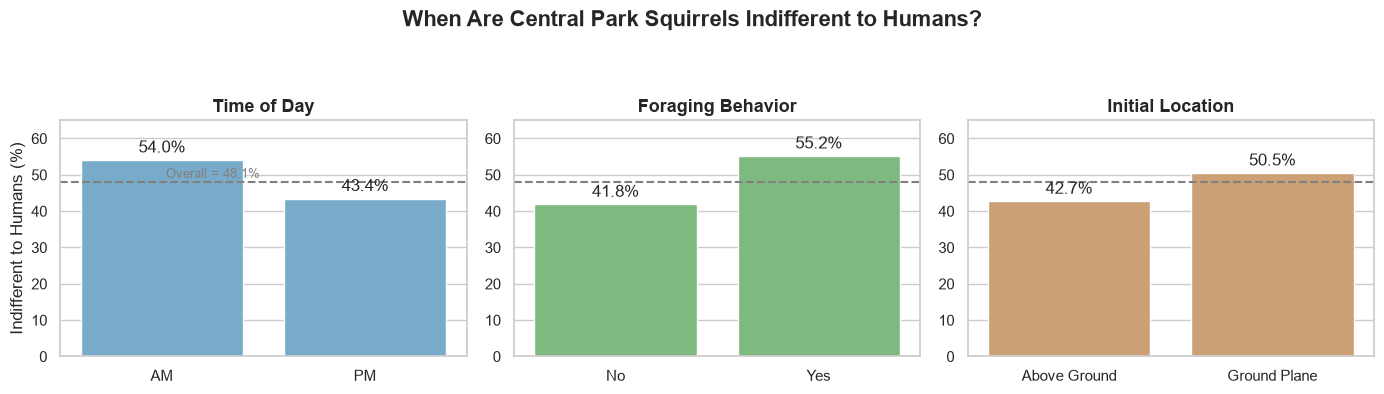

In [23]:
location_plot = location_summary[
    location_summary["Location"] != "Unknown"
].copy()

foraging_plot = foraging_summary.copy()
foraging_plot["Foraging"] = foraging_plot["Foraging"].map({
    False: "No",
    True: "Yes"
})

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.barplot(
    data=shift_summary,
    x="Shift",
    y="Percent indifferent",
    color="#6BAED6",
    ax=axes[0]
)

sns.barplot(
    data=foraging_plot,
    x="Foraging",
    y="Percent indifferent",
    color="#74C476",
    ax=axes[1]
)

sns.barplot(
    data=location_plot,
    x="Location",
    y="Percent indifferent",
    color="#D9A066",
    ax=axes[2]
)

titles = [
    "Time of Day",
    "Foraging Behavior",
    "Initial Location"
]

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylim(0, 65)

    ax.axhline(
        overall_rate * 100,
        color="gray",
        linestyle="--",
        linewidth=1.5
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3
        )

axes[0].set_ylabel("Indifferent to Humans (%)")
axes[1].set_ylabel("")
axes[2].set_ylabel("")

axes[0].text(
    0.02,
    overall_rate * 100 + 1,
    "Overall = 48.1%",
    color="gray",
    fontsize=9
)

fig.suptitle(
    "When Are Central Park Squirrels Indifferent to Humans?",
    fontsize=16,
    fontweight="bold"
)

fig.tight_layout(rect=[0, 0, 1, 0.9])

fig.savefig(
    "indifferent_comparisons.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Exploratory Findings

I found a few patterns in the data.

Squirrels were more likely to be recorded as indifferent in the **morning** than in the afternoon. Indifference was also more common for squirrels that were **foraging** and squirrels that were observed on the **ground**.

Out of these patterns, foraging showed the biggest difference.

These are just patterns in the data, so they do not necessarily mean that these factors cause squirrels to ignore humans.


## 5. Prepare the Data for Classification

The goal here is to predict whether a squirrel was recorded as **indifferent to humans**.

For the predictors, I used information about the squirrel's traits, behavior, location, time of day, and observation conditions.

I left out `Approaches`, `Runs from`, and `Other Interactions` because they already describe how the squirrel interacted with humans. Using them would make the prediction too easy and could lead to target leakage.


In [24]:
predictors = [
    "Age",
    "Primary Fur Color",
    "Location",
    "Shift",
    "X",
    "Y",
    "Hectare Conditions",
    "Number of sighters",
    "Running",
    "Chasing",
    "Climbing",
    "Eating",
    "Foraging",
    "Kuks",
    "Quaas",
    "Tail flags",
    "Tail twitches"
]

X = data_clean[predictors].copy()
y = data_clean["Indifferent"].astype(int)

In [25]:
boolean_predictors = [
    "Running",
    "Chasing",
    "Climbing",
    "Eating",
    "Foraging",
    "Kuks",
    "Quaas",
    "Tail flags",
    "Tail twitches"
]

X[boolean_predictors] = X[boolean_predictors].astype(int)

In [26]:
categorical_predictors = [
    "Age",
    "Primary Fur Color",
    "Location",
    "Shift",
    "Hectare Conditions"
]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_predictors,
    drop_first=True,
    dtype=int
)

In [27]:
print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)
print("Target shape:", y.shape)
print("Total missing values:", X_encoded.isna().sum().sum())

Original X shape: (3014, 17)
Encoded X shape: (3014, 24)
Target shape: (3014,)
Total missing values: 0


## 6. Train/Test Split and Baseline

I used a stratified 75/25 split so the proportion of indifferent squirrels stayed almost identical in the training and testing sets. The baseline always predicts the most common class.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [29]:
print("X train shape:", X_train.shape)
print("X test shape:", X_test.shape)
print("y train shape:", y_train.shape)
print("y test shape:", y_test.shape)

print()
print(f"Training indifferent rate: {y_train.mean():.1%}")
print(f"Testing indifferent rate: {y_test.mean():.1%}")

X train shape: (2260, 24)
X test shape: (754, 24)
y train shape: (2260,)
y test shape: (754,)

Training indifferent rate: 48.1%
Testing indifferent rate: 48.1%


In [30]:
baseline_prediction = y_train.mode()[0]

baseline_accuracy = (y_test == baseline_prediction).mean()

print("Baseline prediction:", baseline_prediction)
print(f"Baseline accuracy: {baseline_accuracy:.1%}")

Baseline prediction: 0
Baseline accuracy: 51.9%


## 7. Logistic Regression

I first trained a logistic regression model. Logistic regression estimates the probability that an observation belongs to class 1, which in this project means that the squirrel was indifferent to humans.

In [31]:
logistic_model = LogisticRegression(max_iter=2000)

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

In [32]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(f"Baseline accuracy: {baseline_accuracy:.1%}")
print(f"Logistic regression accuracy: {logistic_accuracy:.1%}")
print(
    f"Improvement over baseline: "
    f"{logistic_accuracy - baseline_accuracy:.1%}"
)

Baseline accuracy: 51.9%
Logistic regression accuracy: 59.8%
Improvement over baseline: 8.0%


In [33]:
logistic_matrix = confusion_matrix(
    y_test,
    logistic_predictions
)

print(logistic_matrix)

[[251 140]
 [163 200]]


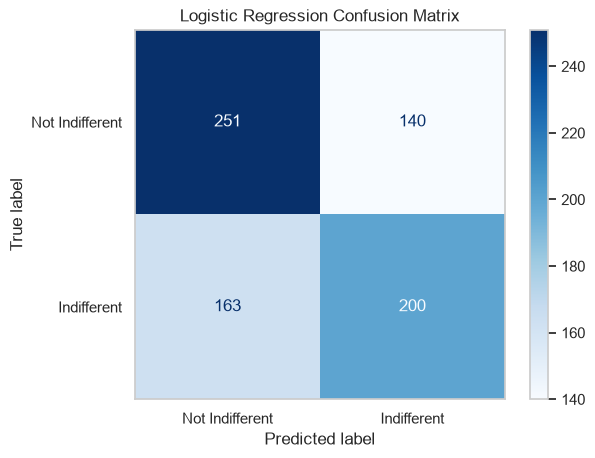

In [34]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=[
        "Not Indifferent",
        "Indifferent"
    ],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.grid(False)
plt.show()

### Logistic Regression Result

The logistic regression model achieved 59.8% testing accuracy, compared with the baseline accuracy of 51.9%. This is an improvement of 8.0 percentage points. The model performed better than the baseline, but it still misclassified many observations.

## 8. Random Forest

I next trained a random forest, which combines many decision trees and can represent nonlinear relationships and interactions between predictors.

In [35]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

forest_predictions = random_forest_model.predict(X_test)

In [36]:
forest_accuracy = accuracy_score(
    y_test,
    forest_predictions
)

print(f"Baseline accuracy: {baseline_accuracy:.1%}")
print(f"Logistic regression accuracy: {logistic_accuracy:.1%}")
print(f"Random forest accuracy: {forest_accuracy:.1%}")

Baseline accuracy: 51.9%
Logistic regression accuracy: 59.8%
Random forest accuracy: 63.5%


In [37]:
forest_matrix = confusion_matrix(
    y_test,
    forest_predictions
)

print(forest_matrix)

[[258 133]
 [142 221]]


In [38]:
logistic_train_predictions = logistic_model.predict(X_train)
forest_train_predictions = random_forest_model.predict(X_train)

logistic_train_accuracy = accuracy_score(
    y_train,
    logistic_train_predictions
)

forest_train_accuracy = accuracy_score(
    y_train,
    forest_train_predictions
)

print("Logistic regression")
print(f"Training accuracy: {logistic_train_accuracy:.1%}")
print(f"Testing accuracy: {logistic_accuracy:.1%}")

print()

print("Random forest")
print(f"Training accuracy: {forest_train_accuracy:.1%}")
print(f"Testing accuracy: {forest_accuracy:.1%}")

Logistic regression
Training accuracy: 60.0%
Testing accuracy: 59.8%

Random forest
Training accuracy: 100.0%
Testing accuracy: 63.5%


## 9. Cross-Validation and Model Comparison

The random forest achieved perfect training accuracy, which suggested possible overfitting. I used five-fold cross-validation to check whether performance was consistent across different subsets of the training data.

In [39]:
logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

forest_cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

In [40]:
print("Logistic regression CV scores:")
print(logistic_cv_scores)
print(f"Mean CV accuracy: {logistic_cv_scores.mean():.1%}")

print()

print("Random forest CV scores:")
print(forest_cv_scores)
print(f"Mean CV accuracy: {forest_cv_scores.mean():.1%}")

Logistic regression CV scores:
[0.6039823  0.6039823  0.53982301 0.5619469  0.63274336]
Mean CV accuracy: 58.8%

Random forest CV scores:
[0.65929204 0.62610619 0.61946903 0.66150442 0.66371681]
Mean CV accuracy: 64.6%


### Model Comparison

The random forest got **100% accuracy on the training data**, which means it fit the training set very closely.

However, its average cross-validation accuracy was about **64.6%**, and its test accuracy was **63.5%**. Since these two results were very similar, the test result probably was not just caused by a lucky train-test split.

Overall, the random forest performed better than logistic regression, but the prediction accuracy was still only moderate.


In [41]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Training Accuracy": [
        logistic_train_accuracy * 100,
        forest_train_accuracy * 100
    ],
    "Cross-Validation Accuracy": [
        logistic_cv_scores.mean() * 100,
        forest_cv_scores.mean() * 100
    ],
    "Testing Accuracy": [
        logistic_accuracy * 100,
        forest_accuracy * 100
    ]
})

model_comparison.round(1)

,Model,Training Accuracy,Cross-Validation Accuracy,Testing Accuracy
0,Logistic Regression,60.0,58.8,59.8
1,Random Forest,100.0,64.6,63.5


In [42]:
comparison_long = model_comparison.melt(
    id_vars="Model",
    var_name="Evaluation",
    value_name="Accuracy"
)

comparison_long["Evaluation"] = (
    comparison_long["Evaluation"]
    .str.replace(" Accuracy", "")
)

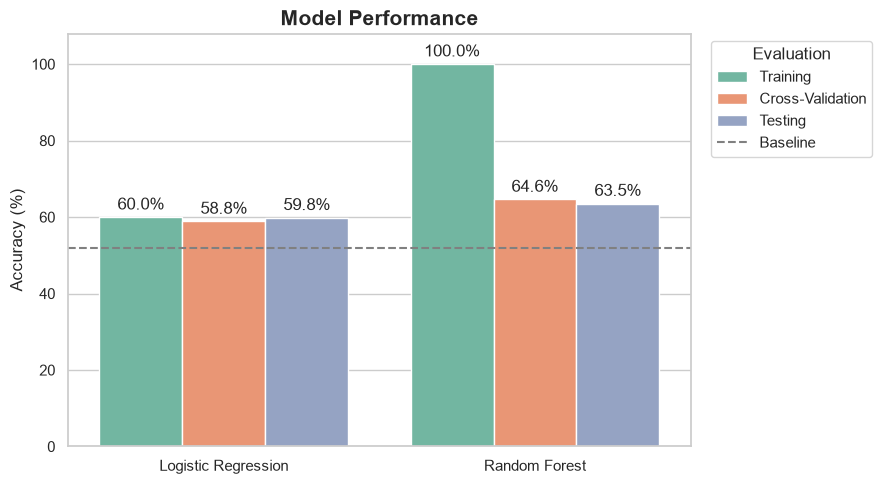

In [43]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=comparison_long,
    x="Model",
    y="Accuracy",
    hue="Evaluation",
    palette="Set2",
    ax=ax
)

ax.axhline(
    baseline_accuracy * 100,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Baseline"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set_ylim(0, 108)
ax.set_xlabel("")
ax.set_ylabel("Accuracy (%)")
ax.set_title(
    "Model Performance",
    fontsize=15,
    fontweight="bold"
)

ax.legend(
    title="Evaluation",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

fig.tight_layout()

fig.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

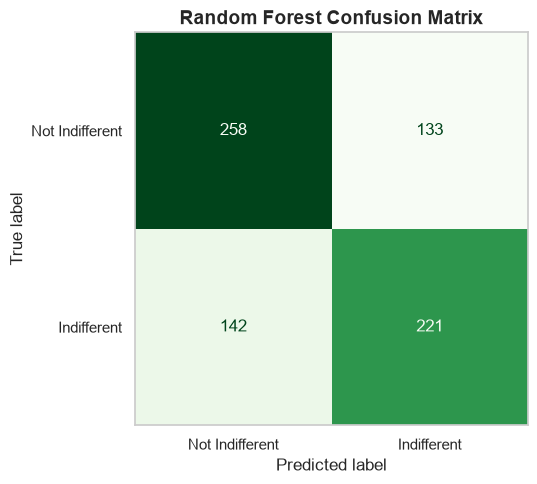

In [44]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=forest_matrix,
    display_labels=[
        "Not Indifferent",
        "Indifferent"
    ]
).plot(
    cmap="Greens",
    colorbar=False,
    ax=ax
)

ax.set_title(
    "Random Forest Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

ax.grid(False)

fig.tight_layout()

fig.savefig(
    "random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Random Forest Result

The random forest correctly predicted **258 out of 391** squirrels that were not indifferent and **221 out of 363** squirrels that were indifferent.

Its test accuracy was **63.5%**, which was better than logistic regression at **59.8%** and the baseline at **51.9%**.

Even though the random forest performed the best, it still made a lot of mistakes and misclassified **275 out of 754** test observations.

So overall, squirrel indifference was somewhat predictable, but there was still a lot that the model could not explain.


## 10. Conclusion

This project looked at whether squirrel traits, behaviors, and environmental conditions could help predict whether a squirrel would ignore humans.

From the exploratory analysis, I found that indifference was more common in the **morning**, among **foraging squirrels**, and among squirrels observed on the **ground**.

The **random forest performed the best**, with **64.6% average cross-validation accuracy** and **63.5% test accuracy**. This was better than logistic regression at **59.8%** and the baseline at **51.9%**. However, the random forest also had **100% training accuracy**, which suggests that it was overfitting the training data.

Overall, squirrel indifference was **somewhat predictable**, but the best model still misclassified **275 out of 754** test observations.

### Limitations

* This is observational data, so these results only show patterns and do not prove that any of these factors caused squirrels to ignore humans.
* Some information was missing or depended on how volunteers recorded their observations.
* `Indifferent` was based on the observer's interpretation of the squirrel's behavior.
* Some squirrels were recorded during the same observation session, so the observations may not be completely independent.
